# An exercise related to the ODE System

We consider the first-order linear differential equation:

$
\frac{dy}{dt} = 3 - y, \qquad y(0)=2
$

Your tasks are:

1. Solve the ODE numerically using `odeint`
2. Solve the ODE numerically using `solve_ivp`
3. Write down the analytical solution
4. Plot and compare all results
5. Briefly describe whether the three solutions agree

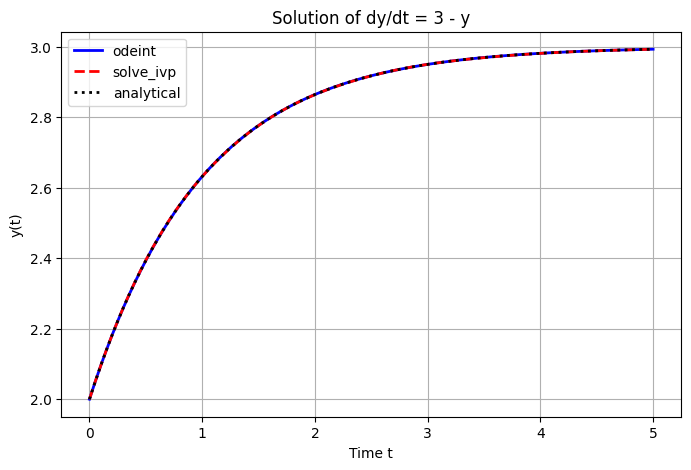

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp

# Define the ODE for odeint: f(y, t)
def f_odeint(y, t):
    return 3 - y

# Define the ODE for solve_ivp: f(t, y)
def f_solve_ivp(t, y):
    return 3 - y

# Initial condition
y0 = 2

# Time points for odeint and plotting
t = np.linspace(0, 5, 100)

# Time span for solve_ivp
t_span = (0, 5)

# Solve using odeint
y_odeint = odeint(f_odeint, y0, t)

# Solve using solve_ivp
sol_ivp = solve_ivp(f_solve_ivp, t_span, [y0], t_eval=t)

# Extract the solution values from solve_ivp
y_solve_ivp = sol_ivp.y[0]

# Analytical solution
y_exact = 3 - np.exp(-t)

# Make odeint output one-dimensional before plotting
y_odeint_plot = y_odeint[:, 0]

# Plot the solutions
plt.figure(figsize=(8, 5))
plt.plot(t, y_odeint_plot, 'b-', label='odeint', linewidth=2)
plt.plot(t, y_solve_ivp, 'r--', label='solve_ivp', linewidth=2)
plt.plot(t, y_exact, 'k:', label='analytical', linewidth=2)

plt.xlabel('Time t')
plt.ylabel('y(t)')
plt.title('Solution of dy/dt = 3 - y')
plt.legend()
plt.grid(True)
plt.show()

# An exercise

In this exercise, you will solve and visualize a **system of first-order ordinary differential equations (ODEs)** using `solve_ivp` from `scipy.integrate`.

Consider the following system:

$$
\begin{cases}
y_1'(t) = y_2(t) \\
y_2'(t) = y_3(t) \\
y_3'(t) = \sin(t) + 2y_3(t) - y_2(t) + 3y_1(t)
\end{cases}
$$

with the initial conditions

$$
y_1(0)=1, \qquad y_2(0)=0, \qquad y_3(0)=2
$$

on the time interval

$$
0 \le t \le 10
$$

## Tasks

1. Import the required libraries.
2. Define the system as a Python function.
3. Set the initial conditions and time interval.
4. Solve the system using `solve_ivp`.
5. Plot $y_1(t)$, $y_2(t)$, and $y_3(t)$ on the same figure.

## Goal

By completing this exercise, you will practice:

- representing a system of ODEs in Python
- using `solve_ivp` to compute numerical solutions
- extracting solution components from the solver output
- plotting multiple solution curves clearly

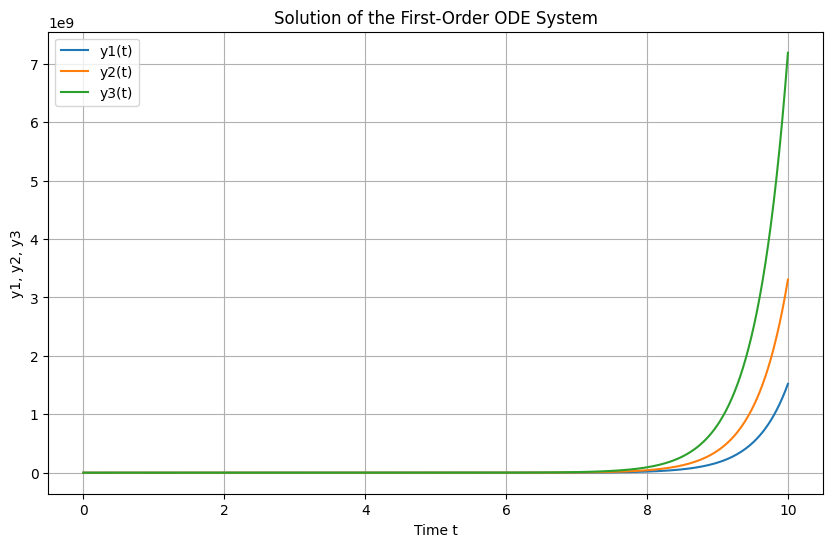

In [ ]:
#Block 1: Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
#Block 2: Define the system of ODEs as a Python function
# The function should return the derivatives [dy1/dt, dy2/dt, dy3/dt]
def system(t, y):
    y1, y2, y3 = y
    dy1_dt = y2
    dy2_dt = y3
    dy3_dt = np.sin(t) + 2*y3 - y2 + 3*y1
    return [dy1_dt, dy2_dt, dy3_dt]
#Block 3: Set the initial conditions and time span
y0 = [1, 0, 2]        # Initial conditions: y1(0)=1, y2(0)=0, y3(0)=2
t_span = (0, 10)      # Time interval for the solution
t_eval = np.linspace(*t_span, 500)  # Time points where solution is evaluated
#Block 4: Solve the ODE using solve_ivp
solution = solve_ivp(system, t_span, y0, t_eval=t_eval)
#Block 5: Plot the results
plt.figure(figsize=(10, 6))
plt.plot(solution.t, solution.y[0], label='y1(t)')
plt.plot(solution.t, solution.y[1], label='y2(t)')
plt.plot(solution.t, solution.y[2], label='y3(t)')
plt.title('Solution of the First-Order ODE System')
plt.xlabel('Time t')
plt.ylabel('y1, y2, y3')
plt.legend()
plt.grid(True)
plt.show()